<a href="https://colab.research.google.com/github/Saddeee/kex/blob/main/KEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
import pandas as pd
import requests
import zipfile
import io
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

def load_data():
  # URL for MovieLens 1M dataset
  url = "http://files.grouplens.org/datasets/movielens/ml-1m.zip"

  # Download the zip file
  response = requests.get(url)
  zip_file = zipfile.ZipFile(io.BytesIO(response.content))

  # Extract and load the 'users.dat' file
  # The file is pipe-separated and has no header, so we define columns
  users_data = zip_file.read('ml-1m/users.dat').decode('latin-1')
  users = pd.read_csv(io.StringIO(users_data), sep='::', engine='python',
                      names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])

  # Extract and load the 'movies.dat' file
  movies_data = zip_file.read('ml-1m/movies.dat').decode('latin-1')
  movies = pd.read_csv(io.StringIO(movies_data), sep='::', engine='python',
                       names=['MovieID', 'Title', 'Genres'])

  # Extract and load the 'ratings.dat' file
  ratings_data = zip_file.read('ml-1m/ratings.dat').decode('latin-1')
  ratings = pd.read_csv(io.StringIO(ratings_data), sep='::', engine='python',
                        names=['UserID', 'MovieID', 'Rating', 'Timestamp'])

  print("MovieLens data loaded successfully!")
  return users, movies, ratings

users_df, movies_df, ratings_df = load_data()

print("\nUsers DataFrame Head:")
display(users_df.head())

print("\nMovies DataFrame Head:")
display(movies_df.head())

print("\nRatings DataFrame Head:")
display(ratings_df.head())


MovieLens data loaded successfully!

Users DataFrame Head:


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455



Movies DataFrame Head:


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy



Ratings DataFrame Head:


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [127]:
"""
class Rating:
  def __init__(self, user_id, movie_id, rating, timestamp):
    self.user_id = user_id
    self.movie_id = movie_id
    self.rating = rating
    self.timestamp = timestamp
  def __str__(self):
    return f"{self.user_id}, {self.movie_id}, {self.rating}, {self.timestamp}"

# Vad vi borde göra istället: Tag 90 % av varje användares ratings till training och resterande 10 % till validation kanske
#consider only using latest rating of a user då man kan ändra sig något vi kjan ha med i diskusion

# Get first 1000 unique users
first_users = ratings_df["UserID"].unique()[:100]

# Take all reviews for those users
ratings_subset = ratings_df[ratings_df["UserID"].isin(first_users)]

# Users for each review
users = ratings_subset["UserID"].to_numpy().astype(int)  # one entry per review
items = ratings_subset["MovieID"].to_numpy().astype(int)
ratings = ratings_subset["Rating"].to_numpy()

print(np.shape(ratings))


training_data_share_of_ratings = 0.5

ratings = ratings[:int(len(ratings) * training_data_share_of_ratings)]

latent_space_dim = 2

b_items = np.zeros(ratings_df.MovieID.max() + 1)
q_items = np.random.rand(ratings_df.MovieID.max() + 1, latent_space_dim)

b_users = np.zeros(ratings_df.UserID.max() + 1)
p_users = np.random.rand(ratings_df.UserID.max() + 1, latent_space_dim)

#convert explcit to implicit
#ratings_df['Rating'] = ratings_df['Rating'].apply(lambda x : 1 if x >= 0 else 0)
#print(ratings_df.head())


ratings_numpy = ratings_df.to_numpy()

#slumpa users tag icke rating
def data_preprocessing_sample_negagtive():
  global ratings_numpy
  ratings_numpy = ratings_numpy[ratings_numpy[:, 0] < 100]
  user_to_rating = {}
  rating_preprocessed = np.zeros(np.shape(ratings_numpy))
  test_set = {}
  for row in ratings_numpy:
    user_id = row[0]
    movie_id = row[1]
    ratings = row[2]
    timestamp = row[3]
    ratings = Rating(user_id, movie_id, ratings, timestamp)
    #print(ratings)
    user_to_rating[user_id] = user_to_rating.get(user_id, [])
    user_to_rating[user_id].append(ratings)

  for user,values in user_to_rating.items():
    len_ratings = len(values)
    #sample unseen for that user
    ratings_unseen = set()
    while len(ratings_unseen) < len_ratings:
      sample = np.random.randint(0, movies_df.MovieID.max() + 1)
      if sample not in ratings_unseen:
        for rating in values:
          if rating.movie_id == sample:
            break
        else:
          temp_rating = Rating(user, sample, 0, -1)
          ratings_unseen.add(temp_rating)

    #convert 1D ratigns list -> 2D numpy
    #  1. Extract the data into a list of lists
    new_data = [ [r.user_id, r.movie_id, r.rating, r.timestamp]  for r in ratings_unseen]

    # 2. Convert to NumPy
    ratings_unseen_array = np.array(new_data)

    # 3. Combine with your existing array
    # (Assuming ratings_numpy is already a NumPy array)
    ratings_numpy = np.vstack((ratings_numpy, ratings_unseen_array))
  return ratings_numpy

#ratings_numpy = data_preprocessing_sample_negagtive()


def data_preprocessing_leave_one_out():
  #exclude single people from data.
  global ratings_numpy
  #leave one out
  #cut ratings numpy
  ratings_numpy = ratings_numpy[ratings_numpy[:, 0] < 100]
  user_to_rating = {}
  rating_preprocessed = np.zeros(np.shape(ratings_numpy))
  test_set = {}
  for row in ratings_numpy:
    user_id = row[0]
    movie_id = row[1]
    ratings = row[2]
    timestamp = row[3]
    ratings = Rating(user_id, movie_id, ratings, timestamp)
    #print(ratings)
    user_to_rating[user_id] = user_to_rating.get(user_id, [])
    user_to_rating[user_id].append(ratings)

  for key, value in user_to_rating.items():
    if(len(value) == 1):
      del user_to_rating[key]
    #print(value[0])
    value.sort(key=lambda x: x.timestamp)
    test_set[key] = value[-1]
    value = value[:-1]
  return user_to_rating, test_set

training_split, test_set = data_preprocessing_leave_one_out()


for key, value in training_split.items():
  print(key)
  for i in value:
    print(i)
for key, value in test_set.items():
    print(i)
"""












'\nclass Rating:\n  def __init__(self, user_id, movie_id, rating, timestamp):\n    self.user_id = user_id\n    self.movie_id = movie_id\n    self.rating = rating\n    self.timestamp = timestamp\n  def __str__(self):\n    return f"{self.user_id}, {self.movie_id}, {self.rating}, {self.timestamp}"\n\n# Vad vi borde göra istället: Tag 90 % av varje användares ratings till training och resterande 10 % till validation kanske\n#consider only using latest rating of a user då man kan ändra sig något vi kjan ha med i diskusion\n\n# Get first 1000 unique users\nfirst_users = ratings_df["UserID"].unique()[:100]\n\n# Take all reviews for those users\nratings_subset = ratings_df[ratings_df["UserID"].isin(first_users)]\n\n# Users for each review\nusers = ratings_subset["UserID"].to_numpy().astype(int)  # one entry per review\nitems = ratings_subset["MovieID"].to_numpy().astype(int)\nratings = ratings_subset["Rating"].to_numpy()\n\nprint(np.shape(ratings))\n\n\ntraining_data_share_of_ratings = 0.5\n\n

In [128]:
# Rating class
class Rating:

    def __init__(self, user_id, movie_id, rating, timestamp):

        self.user_id = user_id
        self.movie_id = movie_id
        self.rating = rating
        self.timestamp = timestamp

    def __str__(self):

        return f"{self.user_id}, {self.movie_id}, {self.rating}, {self.timestamp}"


# -----------------------------
# Leave-One-Out Split
# -----------------------------
def data_preprocessing_leave_one_out(ratings_numpy):

    if not isinstance(ratings_numpy, dict):
      user_to_rating = defaultdict(list)
      for row in ratings_numpy:
          user_id = int(row[0])
          movie_id = int(row[1])
          rating = float(row[2])
          timestamp = int(row[3])
          r = Rating(user_id, movie_id, rating, timestamp)
          user_to_rating[user_id].append(r)
      train = {}
      test = {}
      for user, values in user_to_rating.items():
          if len(values) < 2:
              continue
          values.sort(key=lambda x: x.timestamp)
          test[user] = values[-1]
          train[user] = values[:-1]
      return train, test
    else:
      user_to_rating = defaultdict(list)
      for user, ratings in ratings_numpy.items():
        for rating in ratings:
          r = Rating(user, rating.movie_id, rating.rating, rating.timestamp)
          user_to_rating[user].append(r)
      train = {}
      test = {}
      for user, values in user_to_rating.items():
          if len(values) < 2:
              continue
          values.sort(key=lambda x: x.timestamp)
          test[user] = values[-1]
          train[user] = values[:-1]
      return train, test


# -----------------------------
# Negative Sampling (implicit training only)
# -----------------------------
def add_negative_samples(train_dict, num_movies):
    implicit_train = {}
    for user, values in train_dict.items():
        rated_movies = {r.movie_id for r in values}
        new_values = list(values)
        num_negatives = len(values)
        negatives = set()
        while len(negatives) < num_negatives:
            sample = np.random.randint(1, num_movies + 1)
            if sample not in rated_movies:
                negatives.add(sample)
        for movie in negatives:
            new_values.append(Rating(user, movie, 0, -1))
        implicit_train[user] = new_values
    return implicit_train

In [129]:
# -----------------------------
# RMSE
# -----------------------------
def rmse(test, b_users, b_items, p_users, q_items):
    errors = []
    for user, r in test.items():
        pred = predict(r.user_id, r.movie_id, b_users, b_items, p_users, q_items)
        errors.append((r.rating - pred)**2)
    return np.sqrt(np.mean(errors))

# -----------------------------
# HitRate@10
# -----------------------------
def evaluate_implicit(train, test, num_movies, b_users, b_items, p_users, q_items, K=10):
    hits = 0
    total = 0
    for user, r in test.items():
        rated_movies = {x.movie_id for x in train[user]}
        negatives = set()
        while len(negatives) < 100:
            movie = np.random.randint(1, num_movies + 1)
            if movie not in rated_movies and movie != r.movie_id:
                negatives.add(movie)
        candidates = list(negatives)
        candidates.append(r.movie_id)
        scores = []
        for movie in candidates:
            scores.append((movie, predict(user,movie, b_users, b_items, p_users, q_items)))
        scores.sort(key=lambda x: x[1], reverse=True)
        top_k = [x for x,_ in scores[:K]]
        if r.movie_id in top_k:
            hits += 1
        total += 1
    return hits / total

# NDCG
def evaluate_implicit_ndcg(train, test, num_movies, b_users, b_items, p_users, q_items, num_negatives=99, top_k=10):
    np.random.seed(42)
    total_ndcg = 0

    for user, r in test.items():
        rated_movies = {x.movie_id for x in train[user]}

        # Use num_negatives for the "Difficulty"
        negatives = set()
        while len(negatives) < num_negatives:
            movie = np.random.randint(1, num_movies + 1)
            if movie not in rated_movies and movie != r.movie_id:
                negatives.add(movie)

        candidates = list(negatives)
        candidates.append(r.movie_id)

        scores = np.zeros(len(candidates))
        for i, movie in enumerate(candidates):
            scores[i] = predict(user, movie, b_users, b_items, p_users, q_items)

        ranking = np.argsort(scores)[::-1]
        pos_index = len(candidates) - 1
        rank = np.where(ranking == pos_index)[0][0]

        # Use top_k for the "Cutoff" (Score)
        if rank < top_k:
            total_ndcg += 1 / np.log2(rank + 2)

    return total_ndcg / len(test)



# NDCG for exlcit
def evaluate_explicit_ndcg(train, test, num_movies, b_users, b_items, p_users, q_items, K=10):

  mean = 0
  for user, r in test.items():
        rated_movies = {x.movie_id for x in train[user]}

        negatives = set()
        while len(negatives) < K:
            movie = np.random.randint(1, num_movies + 1)
            if movie not in rated_movies and movie != r.movie_id:
                negatives.add(movie)

        candidates = list(negatives)
        candidates.append(r.movie_id)

        scores = np.zeros(K+1)

        for i, movie in enumerate(candidates):
            scores[i] = predict(user, movie, b_users, b_items, p_users, q_items)

        # Ranking
        ranking = np.argsort(scores)[::-1]

        # find position of the positive item
        pos_index = candidates.index(r.movie_id)
        rank = np.where(ranking == pos_index)[0][0]

        rel = r.rating   # explicit rating

        # DCG
        dcg = (2**rel - 1) / np.log2(rank + 2)

        # IDCG (ideal: item ranked first)
        idcg = (2**rel - 1) / np.log2(1 + 1)

        final = dcg / idcg

        mean += final

  return mean / len(test)


def evaluate_ndcg_wrapper(train, test, num_movies, b_users, b_items, p_users, q_items, flag, top_k=10):
    if flag == "implicit":
        return evaluate_implicit_ndcg(train, test, num_movies, b_users, b_items, p_users, q_items, top_k)
    else:
        return evaluate_explicit_ndcg(train, test, num_movies, b_users, b_items, p_users, q_items, top_k)




In [130]:
# -----------------------------
# Subset of users
# -----------------------------
first_users = ratings_df["UserID"].unique()[:100]
ratings_subset = ratings_df[ratings_df["UserID"].isin(first_users)]
ratings_numpy = ratings_subset.to_numpy()

tmp_training_split, test_set = data_preprocessing_leave_one_out(ratings_numpy)
training_split, validation_set = data_preprocessing_leave_one_out(tmp_training_split)

implicit_training_split = add_negative_samples(training_split,ratings_df.MovieID.max())

# -----------------------------
# Matrix Factorization Params
# -----------------------------
#latent_space_dim = 20
num_users = ratings_df.UserID.max() + 1
num_items = ratings_df.MovieID.max() + 1



global_mean = ratings_subset["Rating"].mean()

def predict(u,i, b_users, b_items, p_users, q_items):
    return global_mean + b_users[u] + b_items[i] + np.dot(p_users[u], q_items[i])

# -----------------------------
# Training
# -----------------------------
def train(train_data, b_users, b_items, p_users, q_items, epochs=10, lr=0.01, reg=0.02):
    samples = []
    for user, values in train_data.items():
        for r in values:
            samples.append((r.user_id, r.movie_id, r.rating))
    for epoch in range(epochs):
        random.shuffle(samples)
        loss = 0
        for u,i,r in samples:
            pred = predict(u,i, b_users, b_items, p_users, q_items)
            err = r - pred
            loss += err**2
            b_users[u] += lr * (err - reg*b_users[u])
            b_items[i] += lr * (err - reg*b_items[i])
            pu = p_users[u]
            qi = q_items[i]
            p_users[u] += lr*(err*qi - reg*pu)
            q_items[i] += lr*(err*pu - reg*qi)
        loss /= len(samples)
        yield loss  # return loss each epoch

#hyperparameter tuning
def hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items, top_k=1):
    K_values = [8, 16, 32, 64]
    best_k = 0
    # Change logic to "Higher is Better" for NDCG
    best_ndcg = -np.inf


    best_params = {}
    results = {}
    best_eval_for_k = {}

    for k in K_values:
        b_items = np.zeros(num_items+1)
        q_items = np.random.normal(0, 0.1, (num_items+1, k))
        b_users = np.zeros(num_users+1)
        p_users = np.random.normal(0, 0.1, (num_users+1, k))

        current_k_losses = []

        best_local = -np.inf

        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items)):
            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag,top_k=top_k )
            current_k_losses.append(loss)
            if current_ndcg > best_local:
                best_local = current_ndcg
                best_eval_for_k[k] = current_ndcg

            # Update best parameters if NDCG improved
            if current_ndcg > best_ndcg:
                best_ndcg = current_ndcg
                best_k = k
                # Capture the state of the best model
                best_params = {
                    'b_items': b_items.copy(),
                    'q_items': q_items.copy(),
                    'b_users': b_users.copy(),
                    'p_users': p_users.copy()
                }


        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return best_params['b_items'], best_params['q_items'], best_params['b_users'], best_params['p_users'], results, best_eval_for_k





---- Implicit SVD ----

Best K found: 8
Highest NDCG: 0.9372580581071471
Test RMSE: 1.5003554542708428
HitRate@10: 0.81

K: 8, NDCG: 0.06274194189285287
K: 16, NDCG: 0.07750475174999438
K: 32, NDCG: 0.06274194189285287
K: 64, NDCG: 0.08488615667856547


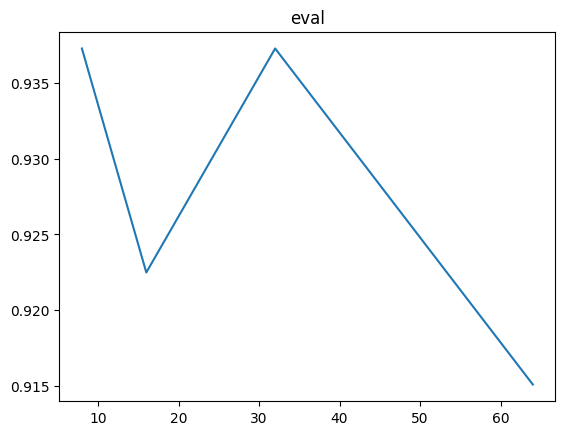

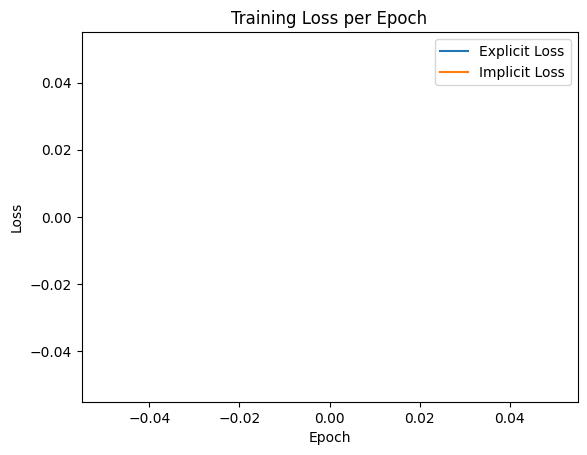

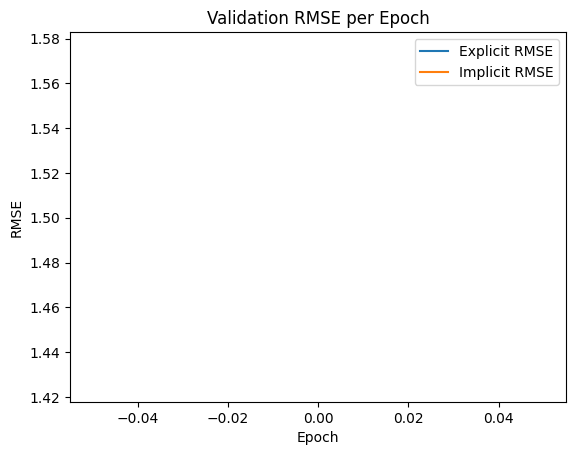

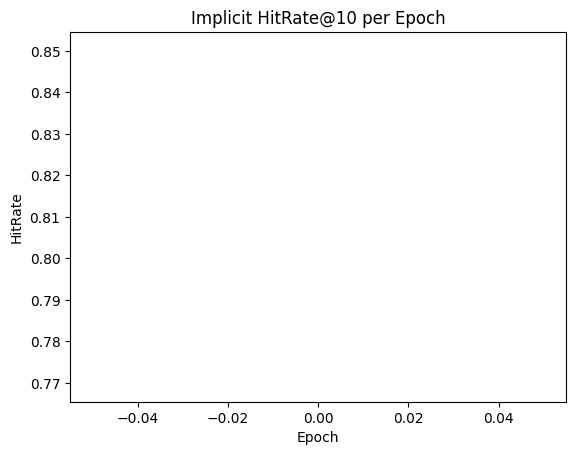

In [135]:
explicit_losses = []
explicit_rmse = []
explicit_ndgc = []

implicit_losses = []
implicit_rmse = []
implicit_hr = []


# -----------------------------
# EXPERIMENT 2: Implicit SVD
# -----------------------------
print("\n---- Implicit SVD ----\n")
for i in test_set:
  ratingobj = test_set[i]
  ratingobj.rating = 1

for i in validation_set:
  ratingobj = validation_set[i]
  ratingobj.rating = 1

b_items, q_items, b_users,p_users, results, best_eval_for_k = hyperparameter_tuning(implicit_training_split, validation_set, "implicit", num_users, num_items, top_k=1)
test_rmse = rmse(test_set, b_users, b_items, p_users, q_items)
#hr = evaluate_implicit(training_split, test_set, ratings_df.MovieID.max())

#hr = evaluate_implicit_ndcg(training_split, test_set, ratings_df.MovieID.max(), b_users, b_items, p_users, q_items, K=1)
implicit_rmse.append(test_rmse)
implicit_hr.append(hr)
print("Test RMSE:", test_rmse)
print("HitRate@10:", hr)
print()


#print eval for each k
for k, ndcg in best_eval_for_k.items():
    print(f"K: {k}, NDCG: {(ndcg)}")
#plot eval x is k and y is ndcg
plt.figure()
plt.plot(list(best_eval_for_k.keys()), list(best_eval_for_k.values()))
plt.title("eval")


# -----------------------------
# PLOTS
# -----------------------------
plt.figure()
plt.plot(explicit_losses, label="Explicit Loss")
plt.plot(implicit_losses, label="Implicit Loss")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(explicit_rmse, label="Explicit RMSE")
plt.plot(implicit_rmse, label="Implicit RMSE")
plt.title("Validation RMSE per Epoch")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.show()

plt.figure()
plt.plot(implicit_hr)
plt.title("Implicit HitRate@10 per Epoch")
plt.xlabel("Epoch")
plt.ylabel("HitRate")
plt.show()



In [ ]:

gamma = 0.01
lambda4 = 0.02
#mu = ratings.mean()
mu = 0
normalise = 0
for user, ratings in training_split.items():
    for rating in ratings:
      r_ui = rating.rating
      mu += (r_ui)
    normalise += len(ratings)

mu = mu / normalise



max_iterations = 100
i = 0
loss = 1
loss_threshold = 0.1

loss_iterations = []
ii = 0

while (i < max_iterations and loss > loss_threshold):

    loss = 0

    for user, ratings in training_split.items():
        for rating in ratings:
            item = rating.movie_id
            r_ui = rating.rating
            # prediction
            pred = mu + b_users[user] + b_items[item] + np.dot(p_users[user], q_items[item])


            # error
            e_ui = r_ui - pred

            # updates
            b_users[user] += gamma * (e_ui - lambda4 * b_users[user])
            b_items[item] += gamma * (e_ui - lambda4 * b_items[item])

            q_items[item] += gamma * (e_ui * p_users[user] - lambda4 * q_items[item])
            p_users[user] += gamma * (e_ui * q_items[item] - lambda4 * p_users[user])

            loss += e_ui**2


    loss = loss / normalise
    loss_iterations.append(loss)
    i += 1

#plot loss
plt.plot(loss_iterations)
print(loss_iterations[-1])


In [ ]:

loss = 0

for user, ratings in training_split.items():
  for rating in ratings:
    item = rating.movie_id
    r_ui = rating.rating
            # prediction
    pred = mu + b_users[user] + b_items[item] + np.dot(p_users[user], q_items[item])
    e_ui = r_ui - pred
    loss += e_ui**2

loss = loss / normalise

print(loss)


In [ ]:
#HR@10

#sample 100 from users that are unrated.
#
#for each user i interlvall [0,10^6] kolla om rated om inte ratad ta 100. Kolla om den redan rated && tagit med den redan.
#sen predict värdne för 100 indexarna exklusive test då vi redan vet
# sen hoppas på att test finns med bland dessa

#hr = 0

#for user, ratings in training_split.items():
#  seen_samples = set()
 # prediction_list = np.zeros(100)
  #while len(seen_samples) < 100:
   # sample = np.random.randint(0, movies_df.MovieID.max() + 1)
    #if sample not in seen_samples:
     # unfucked_columns = [obj.movie_id for obj in ratings]
      #if sample not in unfucked_columns:
       # seen_samples.add(sample)

  #for sample in seen_samples:
   # pred = np.dot(p_users[user], q_items[sample]) + mu + b_users[user] + b_items[sample]
    #prediction_list.append(pred)
  #rate test movie
  #test_val = test_set[user]
  #prediction_list.append()
  #test_val = test_set[user]



In [ ]:
import matplotlib.pyplot as plt


# 0-based indexing for arrays
first_users_idx = first_users - 1  # if p_users is 0-based

# Plot movies
plt.scatter(q_items[:, 0], q_items[:, 1], c='red', alpha=0.6, label='Movies', s=50)

# Plot only the first 1000 users
plt.scatter(p_users[first_users_idx, 0], p_users[first_users_idx, 1], c='blue', alpha=0.4, label='Users', s=30)

plt.title("2D Latent Space of Users and Movies")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend()
plt.grid(True)
plt.show()